In [1]:
!pip install pennylane

In [4]:
import pennylane as qml

def my_quantum_function(x, y):
    qml.RZ(x, wires=0)
    qml.CNOT(wires=[0,1])
    qml.RY(y, wires=1)
    return qml.expval(qml.Z(wires=1))

In [5]:
dev = qml.device('default.qubit', wires=2)

In [6]:
dev = qml.device('default.qubit', wires=3)

In [7]:
dev_unique_wires = qml.device('default.qubit', wires=['aux', 'q1', 'q2'])

In [8]:
def my_quantum_function(x, y):
    qml.RZ(x, wires='q1')
    qml.CNOT(wires=['aux' ,'q1'])
    qml.RY(y, wires='q2')
    return qml.expval(qml.PauliZ('q2'))

In [9]:
import numpy as np

circuit = qml.QNode(my_quantum_function, dev_unique_wires)

In [11]:
circuit(np.pi/4, 0.7)

np.float64(0.7648421872844884)

In [10]:
print(qml.draw(circuit)(np.pi/4, 0.7))

aux: ───────────╭●─┤     
 q1: ──RZ(0.79)─╰X─┤     
 q2: ──RY(0.70)────┤  <Z>


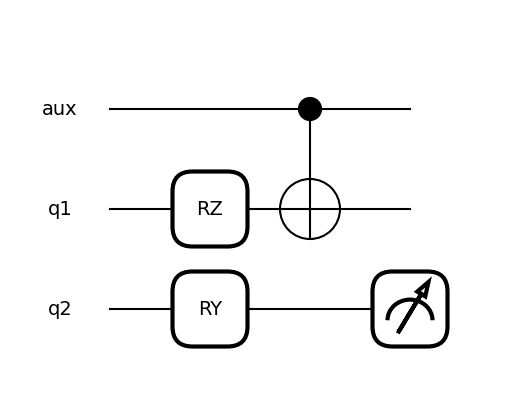

In [12]:
import matplotlib.pyplot as plt
qml.drawer.use_style("black_white")
fig, ax = qml.draw_mpl(circuit)(np.pi/4, 0.7)
plt.show()